In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import math

In [2]:
avgspecs = pd.read_csv('./Average_Spectra_fixed.csv')
del avgspecs['Unnamed: 0']
avgspecs

,Wavelength (nm),Target Reflectance,foldername
0,339.3,27.1465,bent005ck
1,340.8,26.8220,bent005ck
2,342.3,26.1780,bent005ck
3,343.7,25.4310,bent005ck
4,345.2,24.9400,bent005ck
...,...,...,...
15899,2504.7,35.3210,kao5ppfr
15900,2506.7,35.3195,kao5ppfr
15901,2508.8,35.3295,kao5ppfr
15902,2510.9,35.3275,kao5ppfr


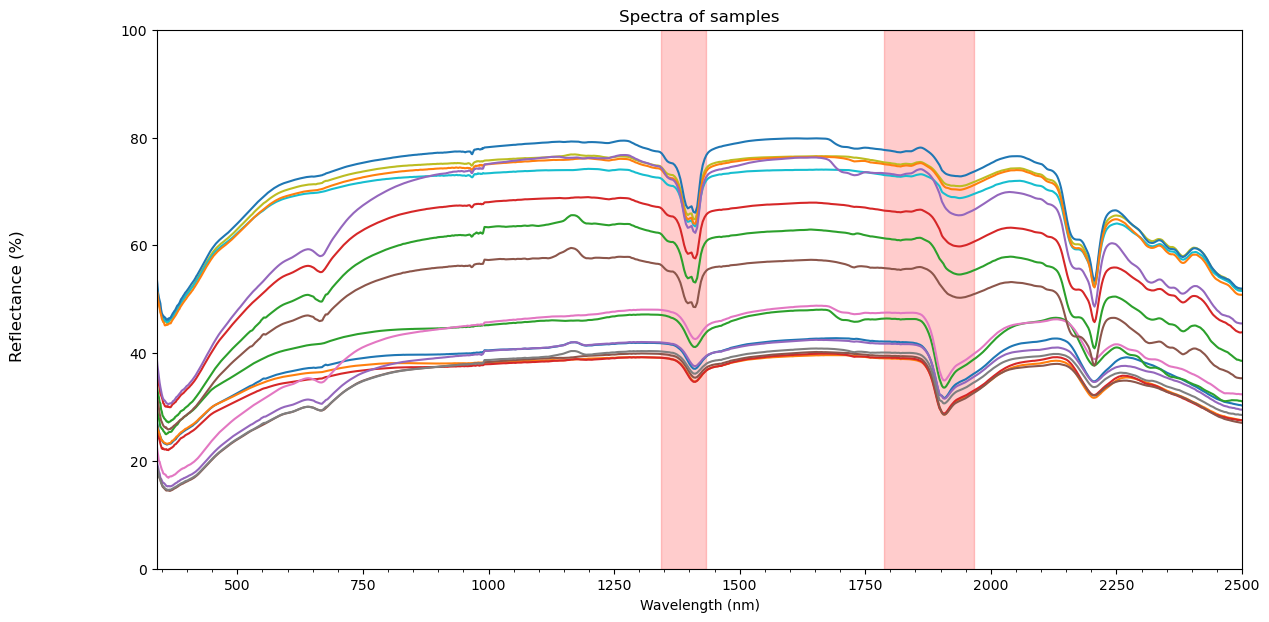

In [3]:
#Creates a figure with each of the avg spectra for each folder

#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(14,7),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,100)

#doing the plotting
foldernames = avgspecs['foldername'].unique()
for i,foldername in enumerate(foldernames):
    ax.plot(avgspecs[avgspecs['foldername']==foldername]['Wavelength (nm)'],avgspecs[avgspecs['foldername']==foldername]['Target Reflectance'],label=foldername) #plots each average spectrum vs the wavelength
ax.fill_betweenx(y=(0,100), x1=1344, x2=1433, color='r',alpha = 0.2, label='Atmospheric Bands from AVIRIS')
ax.fill_betweenx(y=(0,100), x1=1788, x2=1966, color='r',alpha = 0.2)
# ax.legend(loc=2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
# plt.savefig('./Figures/all_avg_spectra.png')
plt.show()

In [4]:
#finding the min value between two wavelengths for all kaolinite samples

avg_absorptions = pd.DataFrame({'Wavelength (nm)':[],'absorption_amplitude':[],'band_depth':[],'foldername':[],'%_change':[]})
#want to find the avg reflectacne of the two bounds to comparee for each spectra of a soil type
for foldername in avgspecs['foldername'].unique():
    if 'kao' in foldername:
        wavemin = 2132 #wavelength where 
        wavemax = 2228
    elif 'bent' in foldername:
        wavemin = 2147
        wavemax = 2248
    filter1 = avgspecs[(avgspecs['Wavelength (nm)'] > wavemin) & (avgspecs['Wavelength (nm)'] < wavemax) & (avgspecs['foldername'] == foldername)]
    localmin = filter1['Target Reflectance'].min() #setting the min as a variable
    filter1['Target Reflectance'].idxmin() #is the index location of the min
    minwave = filter1['Wavelength (nm)'].loc[filter1['Target Reflectance'].idxmin()].item() #is the wavelength at the min
    #boundreflectance = (filter1['Target Reflectance'].iloc[0] + filter1['Target Reflectance'].iloc[-1])/ 2
    x1 = filter1['Wavelength (nm)'].iloc[-1]
    y1 = filter1['Target Reflectance'].iloc[-1]
    x2 = filter1['Wavelength (nm)'].iloc[0]
    y2 = filter1['Target Reflectance'].iloc[0]
    boundreflectance = ((y2-y1)/(x2-x1)*(minwave-x1))+y1
    absorbtion_amp = boundreflectance - localmin 
    banddepth = 1 - (localmin/boundreflectance)
    #print(foldername,'has an absorption amplitude of',absorbtion_amp,'at',filter1['Wavelength (nm)'].loc[filter1['Target Reflectance'].idxmin()],'nm')
    the_deets = pd.DataFrame({'Wavelength (nm)':[filter1['Wavelength (nm)'].loc[filter1['Target Reflectance'].idxmin()]],'absorption_amplitude':[absorbtion_amp],'band_depth':[banddepth],'foldername':[foldername],'%_change':['NaN']})
    avg_absorptions = pd.concat([avg_absorptions,the_deets],ignore_index=True)
    #wanted to calculate the percent change from the sample with plastic compared to the control
for foldername in avg_absorptions['foldername'].unique():
    if 'kao' in foldername:
        if '005' in foldername and 'ck' not in foldername:
            ref = avg_absorptions.loc[avg_absorptions['foldername'] == 'kao005ck','absorption_amplitude'].item()
            avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'%_change'] = ((avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
        elif '5' in foldername and 'ck' not in foldername:
            ref = avg_absorptions.loc[avg_absorptions['foldername'] == 'kao5ck','absorption_amplitude'].item()
            avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'%_change'] = ((avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
    elif 'bent' in foldername:
        if '005' in foldername and 'ck' not in foldername:
            ref = avg_absorptions.loc[avg_absorptions['foldername'] == 'bent005ck','absorption_amplitude'].item()
            avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'%_change'] = ((avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
        elif '5' in foldername and 'ck' not in foldername:
            ref = avg_absorptions.loc[avg_absorptions['foldername'] == 'bent5ck','absorption_amplitude'].item()
            avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'%_change'] = ((avg_absorptions.loc[avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
avg_absorptions

,Wavelength (nm),absorption_amplitude,band_depth,foldername,%_change
0,2204.0,5.318752,0.132706,bent005ck,NaN
1,2204.0,4.566499,0.125866,bent005pem,-14.14342
2,2206.4,5.400983,0.125265,bent005ppfm,1.54605
3,2206.4,4.544372,0.123578,bent005ppfr,-14.559438
4,2206.4,4.077469,0.105320,bent5ck,NaN
5,2206.4,3.770080,0.105009,bent5pem,-7.538726
6,2206.4,4.492402,0.103511,bent5ppfm,10.176252
7,2206.4,3.872631,0.103073,bent5ppfr,-5.023653
8,2206.4,12.184737,0.187432,kao005ck,NaN
9,2206.4,11.135673,0.175406,kao005pem,-8.609659


In [5]:
#Unit Vector Normalization 
# Group by 'foldername' so the norm is calculated for each spectrum individually
avgspecs['reflectance_norm'] = avgspecs.groupby('foldername')['Target Reflectance'].transform(
    lambda x: x / np.linalg.norm(x)
)
avgspecs.to_csv('normalized_specs.csv',index=False)

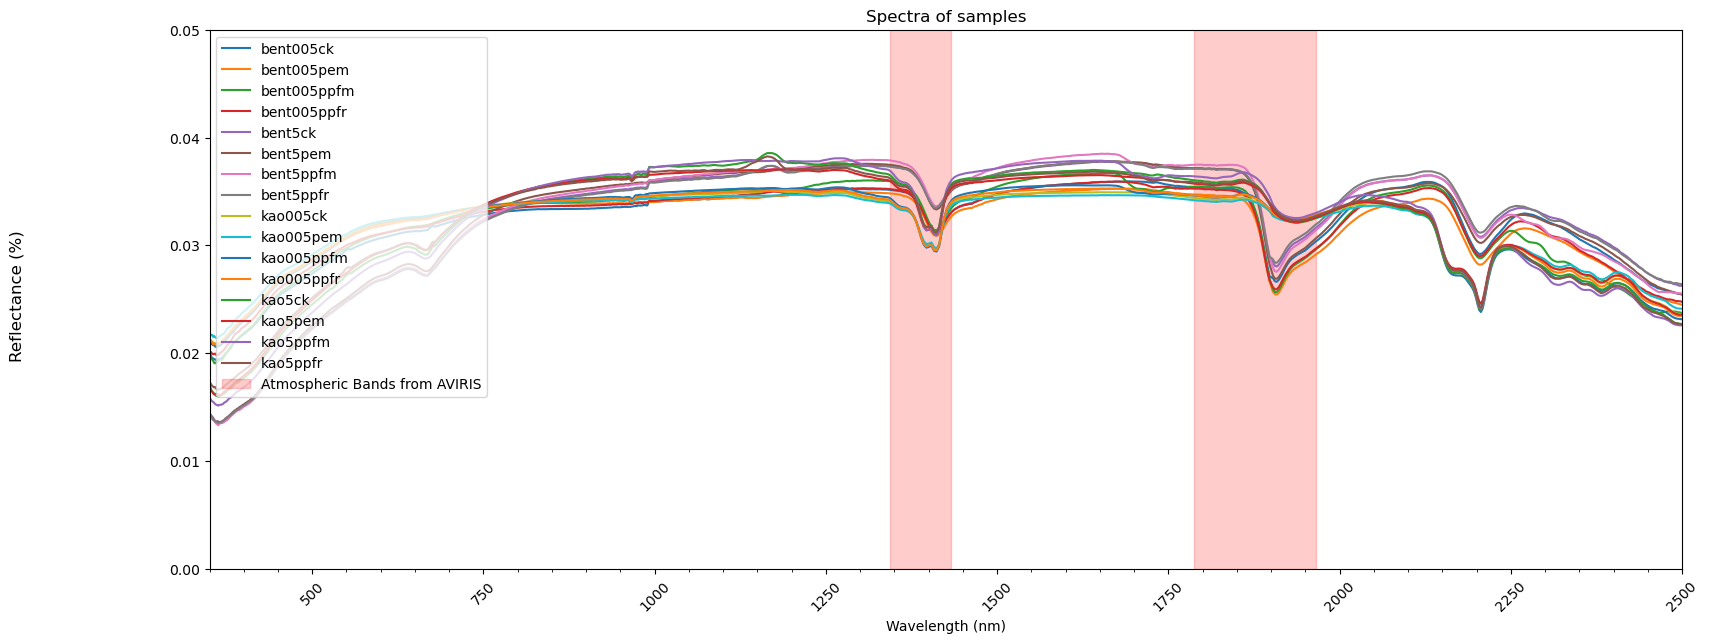

In [6]:
#Creates a figure with each of the avg spectra for each folder

#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(19,7),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
#ax.set_xlim(2000,2300)#(1000,1500)
ax.set_ylim(0.0,0.05)

foldernames = avgspecs['foldername'].unique()
for i,foldername in enumerate(foldernames):
    # can use &(avgspecs['foldername'].str.contains('bent')) in both parts to control the soil types that are plotted
    
    ax.plot(avgspecs[(avgspecs['foldername']==foldername)]['Wavelength (nm)'],avgspecs[(avgspecs['foldername']==foldername)]['reflectance_norm'],label=foldername) #plots each average spectrum vs the wavelength
    # ax.plot(avgspecs[(avgspecs['foldername']==foldername)&(avgspecs['foldername'].str.contains('bent'))]['Wavelength (nm)'],avgspecs[(avgspecs['foldername']==foldername)&(avgspecs['foldername'].str.contains('bent'))]['reflectance_norm'],label=foldername) #plots each average spectrum vs the wavelength
ax.fill_betweenx(y=(0,2), x1=1344, x2=1433, color='r',alpha = 0.2, label='Atmospheric Bands from AVIRIS')
ax.fill_betweenx(y=(0,2), x1=1788, x2=1966, color='r',alpha = 0.2)
ax.legend(loc=2)
#ax.set_xticks(avgspecs['Wavelength (nm)'].unique())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.set_xlim(350,2500)#(1000,1500)
ax.tick_params(axis='x',rotation=45)
plt.savefig('./Figures/normalized_avg_spectra.png')
plt.show()

In [13]:
#finding the min value between two wavelengths for all samples

normalized_avg_absorptions = pd.DataFrame({'Wavelength (nm)':[],'absorption_amplitude':[],'band_depth':[],'foldername':[]})#,'%_change':[]})
#want to find the avg reflectacne of the two bounds to compare for each spectra of a soil type
for foldername in avgspecs['foldername'].unique():
    #defining the bounds of the wavelength for each clay type in the soil
    if 'kao' in foldername:
        wavemin = 2132
        wavemax = 2228
    elif 'bent' in foldername:
        wavemin = 2147
        wavemax = 2248
    filter1 = avgspecs[(avgspecs['Wavelength (nm)'] > wavemin) & (avgspecs['Wavelength (nm)'] < wavemax) & (avgspecs['foldername'] == foldername)]
    localmin = filter1['reflectance_norm'].min() #setting the min as a variable
    filter1['reflectance_norm'].idxmin() #is the index location of the min
    minwave = filter1['Wavelength (nm)'].loc[filter1['reflectance_norm'].idxmin()].item() #is the wavelength at the min

    #defining equation parameters
    x1 = filter1['Wavelength (nm)'].iloc[-1]
    y1 = filter1['reflectance_norm'].iloc[-1]
    x2 = filter1['Wavelength (nm)'].iloc[0]
    y2 = filter1['reflectance_norm'].iloc[0]
    #equations 
    boundreflectance = ((y2-y1)/(x2-x1)*(minwave-x1))+y1
    absorbtion_amp = boundreflectance - localmin 
    banddepth = 1 - (localmin/boundreflectance)
    
    #adding the information about each band depth to a dataframe
    the_deets = pd.DataFrame({'Wavelength (nm)':[filter1['Wavelength (nm)'].loc[filter1['reflectance_norm'].idxmin()]],'absorption_amplitude':[absorbtion_amp],'band_depth':[banddepth],'foldername':[foldername]})
    normalized_avg_absorptions = pd.concat([normalized_avg_absorptions,the_deets],ignore_index=True)

for foldername in normalized_avg_absorptions['foldername'].unique():
    if 'kao' in foldername:
        if '005' in foldername and 'ck' not in foldername:
            ref = normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == 'kao005ck','absorption_amplitude'].item()
            normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'%_change'] = ((normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
        elif '5' in foldername and 'ck' not in foldername:
            ref = normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == 'kao5ck','absorption_amplitude'].item()
            normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'%_change'] = ((normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
    elif 'bent' in foldername:
        if '005' in foldername and 'ck' not in foldername:
            ref = normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == 'bent005ck','absorption_amplitude'].item()
            normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'%_change'] = ((normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
        elif '5' in foldername and 'ck' not in foldername:
            ref = normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == 'bent5ck','absorption_amplitude'].item()
            normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'%_change'] = ((normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername'] == foldername,'absorption_amplitude'].item()-ref)/ref)*100
normalized_avg_absorptions

,Wavelength (nm),absorption_amplitude,band_depth,foldername,%_change
0,2204.0,0.004469,0.132706,bent005ck,NaN
1,2204.0,0.004062,0.125866,bent005pem,-9.101908
2,2206.4,0.004124,0.125265,bent005ppfm,-7.713801
3,2206.4,0.004089,0.123578,bent005ppfr,-8.499114
4,2206.4,0.003625,0.105320,bent5ck,NaN
5,2206.4,0.003546,0.105009,bent5pem,-2.186715
6,2206.4,0.003544,0.103511,bent5ppfm,-2.251165
7,2206.4,0.003583,0.103073,bent5ppfr,-1.158981
8,2206.4,0.005560,0.187432,kao005ck,NaN
9,2206.4,0.005211,0.175406,kao005pem,-6.274471


In [8]:
normalized_avg_absorptions.to_csv('normalized_avg_absorptions.csv',index=False)
avg_absorptions.to_csv('avg_absorptions.csv',index=False)

In [19]:
#This code will give the average % change in band depth based on the type of clay present in the soil
kao_pct_nums = []
bent_pct_nums = []
for foldername in normalized_avg_absorptions['foldername'].unique():
    if 'kao' in foldername and 'ck' not in foldername:
        kao_pct_nums.append(normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'%_change'].item())
    elif 'bent' in foldername and 'ck' not in foldername:
        bent_pct_nums.append(normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'%_change'].item())
print('average change for kaolinite:',pd.Series(kao_pct_nums).mean(),'%')
print('average change for bentoninte:',pd.Series(bent_pct_nums).mean(),'%')

average change for kaolinite: -0.5439753436841436 %
average change for bentoninte: -5.151947431271432 %


In [18]:
#This code will give the average % change in band depth based on the plastic type (regardless of soil type)
pem_pct_nums = []
ppfm_pct_nums = []
pprf_pct_nums = []
for foldername in normalized_avg_absorptions['foldername'].unique():
    if 'pem' in foldername:
        pem_pct_nums.append(normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'%_change'].item())
    elif 'ppfm' in foldername:
        ppfm_pct_nums.append(normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'%_change'].item())
    elif 'ppfr' in foldername:
        pprf_pct_nums.append(normalized_avg_absorptions.loc[normalized_avg_absorptions['foldername']==foldername,'%_change'].item())
print('average change for pem:',pd.Series(pem_pct_nums).mean(),'%')
print('average change for ppfm:',pd.Series(ppfm_pct_nums).mean(),'%')
print('average change for pprf:',pd.Series(pprf_pct_nums).mean(),'%')
print('average change for all plastics:',(pd.Series(pem_pct_nums).mean()+pd.Series(ppfm_pct_nums).mean()+pd.Series(pprf_pct_nums).mean())/3,'%')

average change for pem: -5.60628845551818 %
average change for ppfm: -1.1435995788826405 %
average change for pprf: -1.7939961280325436 %
average change for all plastics: -2.8479613874777883 %
